### Supervised Machine Learning (Binary Classification).

### Data Reading

In [18]:
import keras 
import tensorflow       
from keras.models import Sequential    
from keras.layers import Dense          
from keras.optimizers import Adam 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adult = pd.read_csv(r"C:\ML_Lab\Anaconda\adult.data",header=None)
adult


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### Data Cleaning

In [3]:
adult.columns = ['age','workclass','fnl','education','educational_num','marital_status','occupation','relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','salary']
adult

,age,workclass,fnl,education,educational_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
adult.isnull().sum()

age                0
workclass          0
fnl                0
education          0
educational_num    0
marital_status     0
occupation         0
relationship       0
race               0
sex                0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
salary             0
dtype: int64

In [5]:
# check "?" mark
for i in adult.columns:
    print(i,(adult[i]=='?').sum())

age 0
workclass 0
fnl 0
education 0
educational_num 0
marital_status 0
occupation 0
relationship 0
race 0
sex 0
capital_gain 0
capital_loss 0
hours_per_week 0
native_country 0
salary 0


### Data Vizualization ( Plotting )

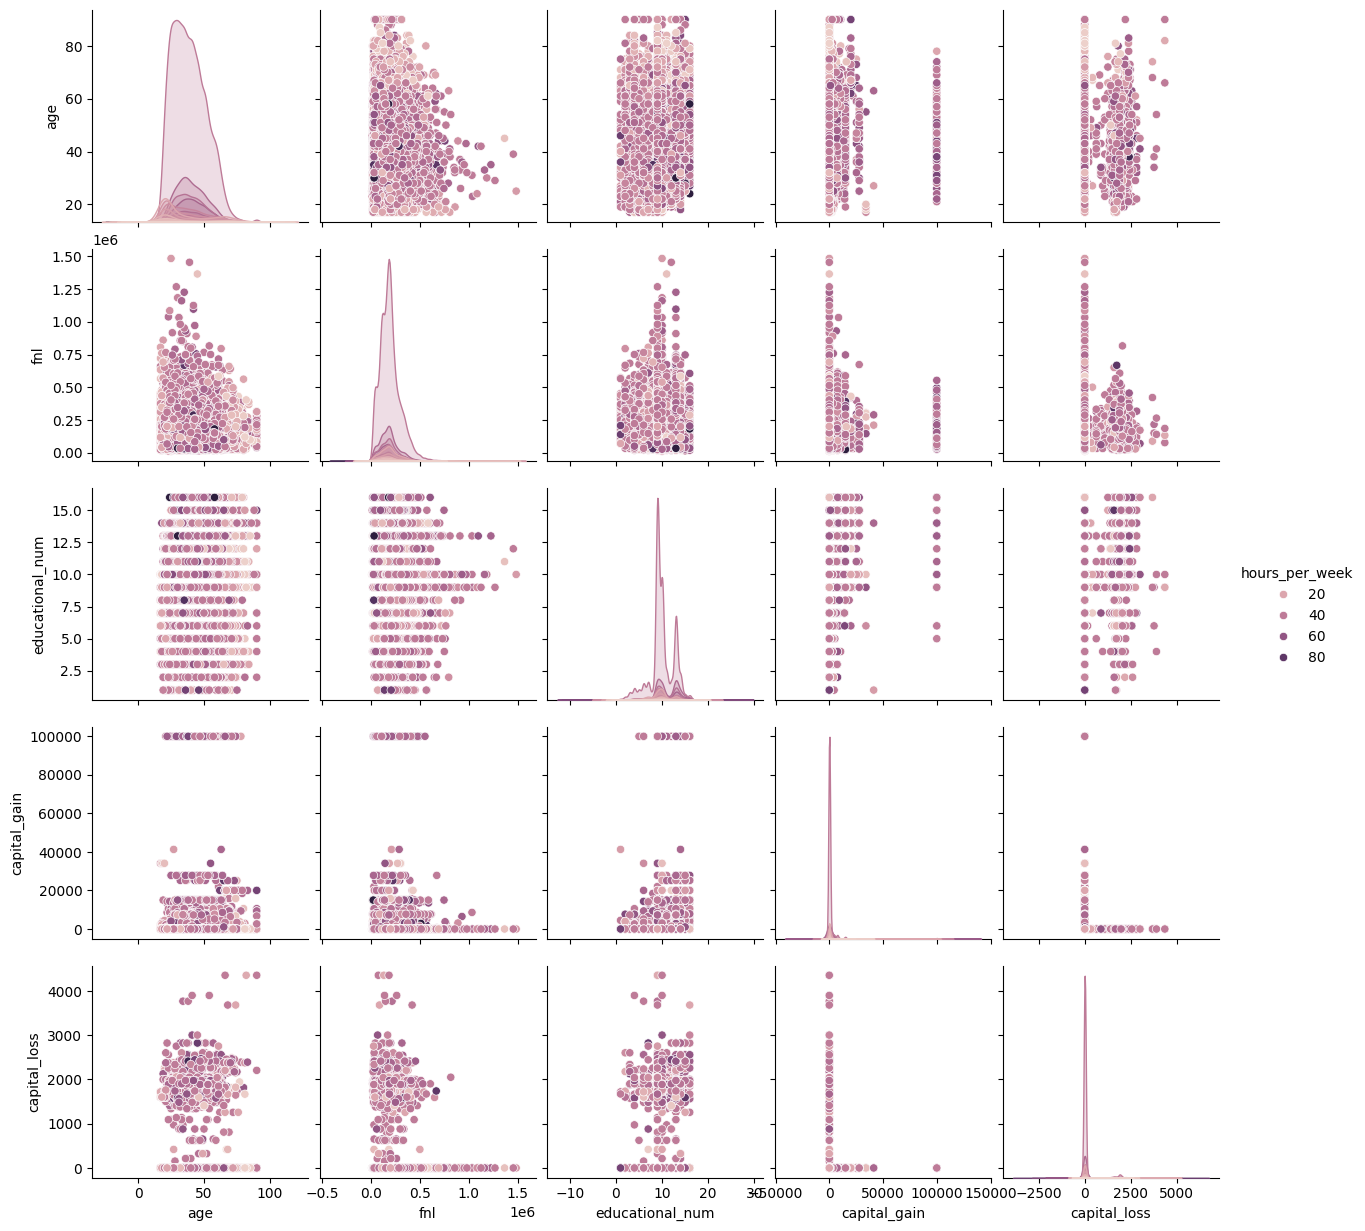

In [6]:
# considering hours_per_week as output ccolumn
sns.pairplot(adult,hue='hours_per_week') # all possible graphs of selling product
plt.show()

<Axes: xlabel='salary', ylabel='count'>

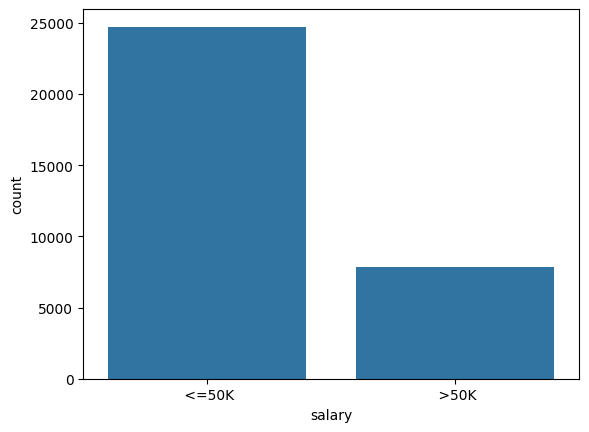

In [7]:
# countplot
sns.countplot(x='salary',data=adult)

### Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in adult.columns:
    if adult[col].dtypes == 'object':
        adult[col] = le.fit_transform(adult[col])


In [9]:
adult.head(2)

,age,workclass,fnl,education,educational_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0


In [10]:
adult.dtypes

age                int64
workclass          int64
fnl                int64
education          int64
educational_num    int64
marital_status     int64
occupation         int64
relationship       int64
race               int64
sex                int64
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country     int64
salary             int64
dtype: object

### Input - Output Creation

In [11]:
ip = adult.drop('hours_per_week',axis=1)
op = adult['hours_per_week']

In [12]:
ip

,age,workclass,fnl,education,educational_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,native_country,salary
0,39,7,77516,9,13,4,1,1,4,1,2174,0,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,0,39,0
32557,40,4,154374,11,9,2,7,0,4,1,0,0,39,1
32558,58,4,151910,11,9,6,1,4,4,0,0,0,39,0
32559,22,4,201490,11,9,4,1,3,4,1,0,0,39,0


In [13]:
op

0        40
1        13
2        40
3        40
4        40
         ..
32556    38
32557    40
32558    40
32559    20
32560    40
Name: hours_per_week, Length: 32561, dtype: int64

### Train_Test_Split


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ip,op,test_size=0.2)

In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train = sc.fit_transform(x_train) # or x_train = sc.transform(x_train)
x_test = sc.fit_transform(x_test)

### Deep learning model creation

In [20]:
model = Sequential()

# input layer
model.add(Dense(40,input_dim=14,activation='linear'))   #14 input columns & 1 output col  # as we have about 32000 data rows

# Hidden layers 
model.add(Dense(45,activation='linear'))
model.add(Dense(55,activation='linear'))
model.add(Dense(65,activation='linear'))

# output
model.add(Dense(1,activation='linear'))
model.compile(Adam(learning_rate=0.01),loss='mae')  # MAE : mean absolute error

In [21]:
# model_fit
model.fit(x_train,y_train,epochs=20,validation_data=(x_test,y_test))

Epoch 1/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 8.7307 - val_loss: 7.6564
Epoch 2/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.7992 - val_loss: 7.8820
Epoch 3/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.7806 - val_loss: 7.5363
Epoch 4/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6503 - val_loss: 7.4739
Epoch 5/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6836 - val_loss: 7.3038
Epoch 6/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6866 - val_loss: 7.4337
Epoch 7/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6183 - val_loss: 7.4761
Epoch 8/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6849 - val_loss: 7.3149
Epoch 9/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.6563 - val_loss: 7.3184
Epoch 10/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6301 - val_loss: 7.3295
Epoch 11/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7.6354 - val_loss: 7.4564
Epoch 12/20
814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [22]:
pred = model.predict(x_test)
pred

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step


array([[40.477314],
       [40.00774 ],
       [41.998577],
       ...,
       [40.63187 ],
       [40.574303],
       [40.282444]], shape=(6513, 1), dtype=float32)

In [23]:
from sklearn.metrics import mean_absolute_error,r2_score
mae = mean_absolute_error(y_test,pred)
r2 = r2_score(y_test,pred)
print("mae:",mae)
print("r2:",r2)

mae: 7.291476726531982
r2: 0.06914317607879639
